In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

(539, 400, 3)


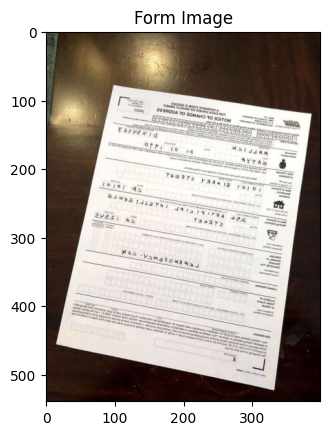

In [2]:
img = cv.flip(cv.imread("../../images/form.png"), 1)
plt.imshow(img[...,::-1]); plt.title("Form Image");
print(img.shape)

In [3]:
def to_gray(img):
    return cv.cvtColor(img, cv.COLOR_BGR2GRAY)

def to_binary(img):
    return cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 2)

def get_edges(img):
    return cv.Canny(img, 100, 200)

def remove_texts(binary_img):
    kernel = cv.getStructuringElement(cv.MORPH_RECT, (5,5))
    return cv.morphologyEx(binary_img, cv.MORPH_CLOSE, kernel, iterations=2)

def denoise(img):
    return cv.GaussianBlur(img,(11,11),2)

def merge_lines(img):
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5,5))
    d = cv.dilate(img, kernel, iterations=2)
    e = cv.erode(d, kernel, iterations=2)
    return e

def order_rectangle_points(pts):
    # pts = [(x1,y1), (x2,y2), (x3,y3), (x4,y4)]

    # Step 1: sort by x coordinate
    pts = sorted(pts, key=lambda p: p[0])

    # leftmost two -> L; rightmost two -> R
    L = sorted(pts[:2], key=lambda p: p[1])   # top-left, bottom-left
    R = sorted(pts[2:], key=lambda p: p[1])   # top-right, bottom-right

    A = L[0]  # top-left
    C = L[1]  # bottom-left
    B = R[0]  # top-right
    D = R[1]  # bottom-right

    return A, B, C, D


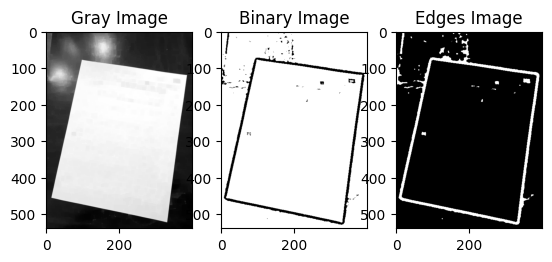

In [4]:
img_gray = to_gray(remove_texts(img))
img_binary = to_binary(denoise(img_gray))
img_edges = merge_lines(get_edges(img_binary))

plt.subplot(131); plt.imshow(img_gray, cmap="gray"); plt.title("Gray Image");
plt.subplot(132); plt.imshow(img_binary, cmap="gray"); plt.title("Binary Image");
plt.subplot(133); plt.imshow(img_edges, cmap="gray"); plt.title("Edges Image");

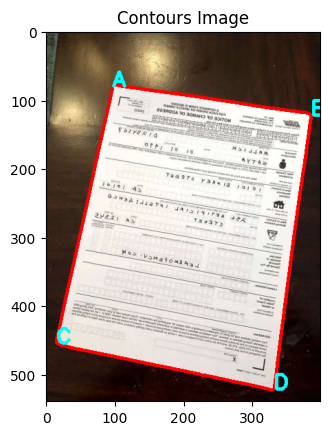

In [5]:
contours, _ = cv.findContours(img_edges, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
draw_img = img.copy()

page_corners = []

for c in contours:
    if cv.contourArea(c) > 1000:
        epsilon = 0.02 * cv.arcLength(c, True)
        corners = cv.approxPolyDP(c, epsilon, True)
        if len(corners) == 4:
            page_corners = corners.reshape(4,2)
            rect = cv.minAreaRect(contours[0])
            box = cv.boxPoints(rect)
            cv.drawContours(draw_img, [c], -1, (0,0,255), 3)

# Displaying the corners.
for index, c in enumerate(order_rectangle_points(page_corners.tolist())):
    character = chr(65 + index)
    cv.putText(draw_img, character, tuple(c), cv.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 3)

plt.imshow(draw_img[...,::-1]); plt.title("Contours Image");